# Atividade prática: Mineração de Dados - Semana 07

Notebook criado para acompanhar as atividades práticas da Semana 07, apresentadas pela disciplina de **Mineração de Dados** da **UNIVESP**.

## Objetivos da Semana 07:

Utilizar o algoritmo **Fator Local de Anomalia (LOF - Local Outlier Factor)** e o **diagrama de caixa** para fazer a detecção de anomalias de uma base de dados que contém as negociações de ações da Petrobrás (PETR4) no período entre novembro de 2019 e abril de 2020.

## Exercícios:

1. Na análise com o LOF, gere um gráfico de dispersão, plotando as anomalias com uma cor diferente dos dados normais. Para a análise, use os atributos Close e Open. Use o parâmetro k-vizinhos = 20. Não precisa definir valor para o parâmetro contamination. Dica: insira rótulos nas anomalias para ver suas datas.
2. Em seguida, calcule os limites inferior e superior dos atributos Close, Open e Volume (use o parâmetro sigma = 1.5) e gere os diagramas de caixa dos três atributos.

### Base de Dados:
https://raw.githubusercontent.com/higoramario/univesp-com360-mineracao-dados/main/petr4-nov-19-abr-20.csv

### Sobre o dataframe:

Os dados foram extraídos do Yahoo! Finanças.  

O **dicionário de dados** é o seguinte:  
* **Date**: data de operação na bolsa.
* **Open**: valor de abertura.
* **High**: valor máximo de negociação no dia.
* **Low**: valor mínimo de negociação no dia.
* **Close**: valor de fechamento.
* **Adj Close**: valor de ajuste de fechamento.
* **Volume**: quantidade de ações negociadas.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np # para delimitar os valores == -1 (outliers identificados pelo LOF)
from sklearn.neighbors import LocalOutlierFactor # algoritmo LOF

In [17]:
plt.rcParams["figure.figsize"] = (15,10) # define um tamanho padrão para os gráficos

In [5]:
url = 'https://raw.githubusercontent.com/higoramario/univesp-com360-mineracao-dados/main/petr4-nov-19-abr-20.csv'
df = pd.read_csv(url)
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2019-11-01,30.590000,31.230000,29.840000,30.430000,24.232862,101210200
1,2019-11-04,30.889999,31.219999,29.959999,30.360001,24.177118,81023400
2,2019-11-05,30.410000,30.600000,29.580000,29.650000,23.611712,92980900
3,2019-11-06,30.049999,30.700001,28.100000,29.709999,23.659489,154003100
4,2019-11-07,30.000000,31.070000,29.540001,30.900000,24.607145,96329000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       106 non-null    object 
 1   Open       106 non-null    float64
 2   High       106 non-null    float64
 3   Low        106 non-null    float64
 4   Close      106 non-null    float64
 5   Adj Close  106 non-null    float64
 6   Volume     106 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 5.9+ KB


### Exercício 1: Análise com LOF

1. Cria uma nova variável (`df1`) para utilizar somente os atributos de interesse;
2. Aplica o algoritmo LOF para detectar anomalias, através dos códigos:
    * `k_vizinhos = 20`: Define o valor que será usado como o número de vizinhos a serem considerados pelo algoritmo LOF para calcular a densidade local de cada ponto de dados;
    * `lof = LocalOutlierFactor(n_neighbors=k_vizinhos)`: Aqui, uma instância do modelo `LocalOutlierFactor` é criada. O parâmetro n_neighbors é configurado com o valor de k_vizinhos (20), indicando que o LOF considerará os 20 vizinhos mais próximos de cada ponto para sua análise;
    * `predicao = lof.fit_predict(df1`): Esta linha executa duas ações principais: primeiro, o modelo LOF é 'treinado' (ajustado) aos dados contidos no DataFrame `df1` (que, neste contexto, são as colunas 'Close' e 'Open'). Em seguida, ele 'prevê' para cada ponto de dados em `df1` se é uma anomalia ou não. O resultado é armazenado na variável `predicao`, onde **1** indica um ponto **normal** (não anômalo) e **-1** indica uma **anomalia** (outlier).
3. Identifica e exibe os pontos de dados que foram classificados como anomalias pelo algoritmo LOF:
    * `lof_outlier = np.where(predicao == -1)`: Função do NumPy que retorna os índices onde a condição predicao == -1 é verdadeira. Ou seja, ela encontra as posições de todos os pontos que foram classificados como anomalias;
    * `lof_outlier`: armazenará esses índices;
    * `anomalias = df1.iloc[lof_outlier]`: `.iloc[lof_outlier]` usa os índices armazenados em `lof_outlier `para selecionar as linhas correspondentes no DataFrame `df1`. Dessa forma, um novo DataFrame chamado `anomalias `é criado, contendo apenas os dados (`'Close'` e `'Open'`) dos pontos que foram identificados como anomalias.
4. Gera o gráfico de dispersão, plotando os valores de 'Close' e 'Open' de todas as ações da Petrobrás, e destacando as anomalias detectadas pelo LOF, além de rotulá-las com suas respectivas datas:
    * `fig, eixo = plt.subplots()`: Cria uma figura (fig) e um conjunto de subplots (eixo). O eixo é o objeto que você usará para plotar os dados;
    * `eixo.scatter(df1['Close'], df1['Open'])`: Plota um gráfico de dispersão com todos os dados do DataFrame `df1`. Os valores de 'Close' estarão no eixo X e 'Open' no eixo Y;
    * `eixo.scatter(anomalias['Close'], anomalias['Open'], color='red')`: Plota novamente um gráfico de dispersão, mas desta vez apenas com os dados que foram identificados como anomalias (armazenados no DataFrame anomalias). Essas anomalias são plotadas na cor vermelha (`color='red'`) para se destacarem;
    * `eixo.set_xlabel('Valor de fechamento')`: Define o rótulo do eixo X como 'Valor de fechamento';
    * `eixo.set_ylabel('Valor de abertura')`: Define o rótulo do eixo Y como 'Volume de abertura';
    * `data_anomalias = df.loc[lof_outlier[0], 'Date']`: Esta linha recupera as datas correspondentes às anomalias. `lof_outlier[0]` contém os índices das linhas que são anomalias no DataFrame original `df`. O `.loc `é usado para selecionar essas linhas e, em seguida, apenas a coluna `'Date'` é extraída;
    * `for i, texto in enumerate(data_anomalias):`: Inicia um loop que itera sobre as datas das anomalias;
    * `eixo.annotate(texto, (anomalias.iloc[i]['Close'], anomalias.iloc[i]['Open']))`: Dentro do loop, para cada anomalia, esta linha adiciona um rótulo de texto (texto, que é a data) no gráfico, na posição correspondente aos valores de 'Close' e 'Open' daquela anomalia;
    * `plt.show():` Exibe o gráfico de dispersão resultante, com as anomalias destacadas em vermelho e suas respectivas datas rotuladas.

In [9]:
df1 = df[['Close','Open']]
df1.head()

,Close,Open
0,30.430000,30.590000
1,30.360001,30.889999
2,29.650000,30.410000
3,29.709999,30.049999
4,30.900000,30.000000


In [10]:
k_vizinhos = 20
lof = LocalOutlierFactor(n_neighbors=k_vizinhos)
predicao = lof.fit_predict(df1)

In [11]:
predicao

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1, -1, -1, -1, -1, -1, -1, -1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1])

In [13]:
lof_outlier = np.where(predicao == -1)
anomalias = df1.iloc[lof_outlier]
anomalias

,Close,Open
55,28.030001,28.629999
60,28.180000,28.520000
75,26.209999,27.040001
76,25.299999,25.719999
77,25.340000,25.160000
78,26.530001,25.500000
79,26.049999,26.570000
80,26.889999,26.910000
81,25.290001,26.330000
82,22.830000,24.100000


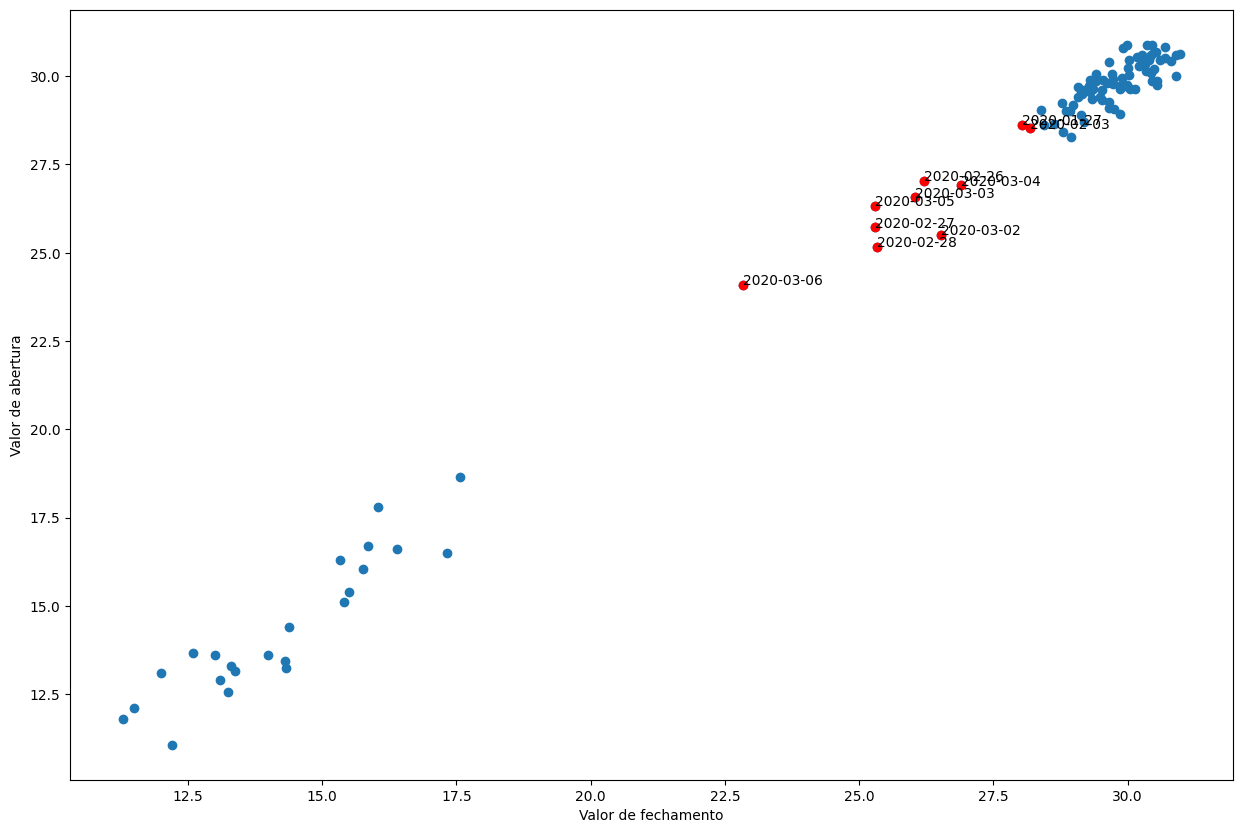

In [41]:
fig, eixo = plt.subplots()

eixo.scatter(df1['Close'], df1['Open'])
eixo.scatter(anomalias['Close'], anomalias['Open'], color='red')
eixo.set_xlabel('Valor de fechamento')
eixo.set_ylabel('Valor de abertura')

data_anomalias = df.loc[lof_outlier[0], 'Date']

for i, texto in enumerate(data_anomalias):
    eixo.annotate(texto, (anomalias.iloc[i]['Close'], anomalias.iloc[i]['Open']))

plt.show()

In [21]:
data_anomalias

,Date
55,2020-01-27
60,2020-02-03
75,2020-02-26
76,2020-02-27
77,2020-02-28
78,2020-03-02
79,2020-03-03
80,2020-03-04
81,2020-03-05
82,2020-03-06


**Explicação da queda das ações (anomalias)**: As ações da Petrobrás tiveram uma queda expressiva entre 21/02/2020 e 20/03/2020, coincidindo, em boa parte, com as datas dos dados anômalos. Essa queda foi consequência de uma disputa entre Rússia e Arábia Saudita que derrubou o preço do petróleo.

### Exercício 2: Limites e Diagramas de caixa

In [23]:
fechamento = df['Close']
abertura = df['Open']
volume = df['Volume']

Calculando os quartis e os intervalos interquartis (IQR) de cada variável:

In [42]:
# fechamento:

fechamento_q1 = df['Close'].quantile(0.25)
fechamento_q3 = df['Close'].quantile(0.75)
fechamento_iqr = fechamento_q3 - fechamento_q1

print(f'Fechamento:\n Q1: {fechamento_q1}, Q3: {fechamento_q3}, IQR: {fechamento_iqr}.')

Fechamento:
 Q1: 25.51749975, Q3: 30.04249925, RI: 4.5249995.


In [43]:
# abertura:

abertura_q1 = df['Open'].quantile(0.25)
abertura_q3 = df['Open'].quantile(0.75)
abertura_iqr = abertura_q3 - abertura_q1

print(f'Abertura:\n Q1: {abertura_q1}, Q3: {abertura_q3}, IQR: {abertura_iqr}.')

Abertura:
 Q1: 25.87249925, Q3: 30.049999, IQR: 4.177499749999999.


In [44]:
# volume:

volume_q1 = df['Volume'].quantile(0.25)
volume_q3 = df['Volume'].quantile(0.75)
volume_iqr = volume_q3 - volume_q1

print(f'Volume:\n Q1: {volume_q1}, Q3: {volume_q3}, IQR: {volume_iqr}.')

Volume:
 Q1: 37563400.0, Q3: 101356975.0, IQR: 63793575.0.


Definindo os limites superior e inferior com o sigma = 1.5

In [31]:
sigma = 1.5

In [45]:
# fechamento:

fechamento_lim_inf = fechamento_q1 - (fechamento_iqr * sigma)
fechamento_lim_sup = fechamento_q3 + (fechamento_iqr * sigma)

print(f'Fechamento:\n Limite inferior: {fechamento_lim_inf}, Limite superior: {fechamento_lim_sup}.')

Fechamento:
 Limite inferior: 18.7300005, Limite superior: 36.8299985.


In [46]:
# abertura:

abertura_lim_inf = abertura_q1 - (abertura_iqr * sigma)
abertura_lim_sup = abertura_q3 + (abertura_iqr * sigma)

print(f'Abertura:\n Limite inferior: {abertura_lim_inf}, Limite superior: {abertura_lim_sup}.')

Abertura:
 Limite inferior: 19.606249625000004, Limite superior: 36.316248625.


In [47]:
# volume:

volume_lim_inf = volume_q1 - (volume_iqr * sigma)
volume_lim_sup = volume_q3 + (volume_iqr * sigma)

print(f'Volume:\n Limite inferior: {volume_lim_inf}, Limite superior: {volume_lim_sup}.')

Volume:
 Limite inferior: -58126962.5, Limite superior: 197047337.5.


Plotando os Diagramas de caixa:

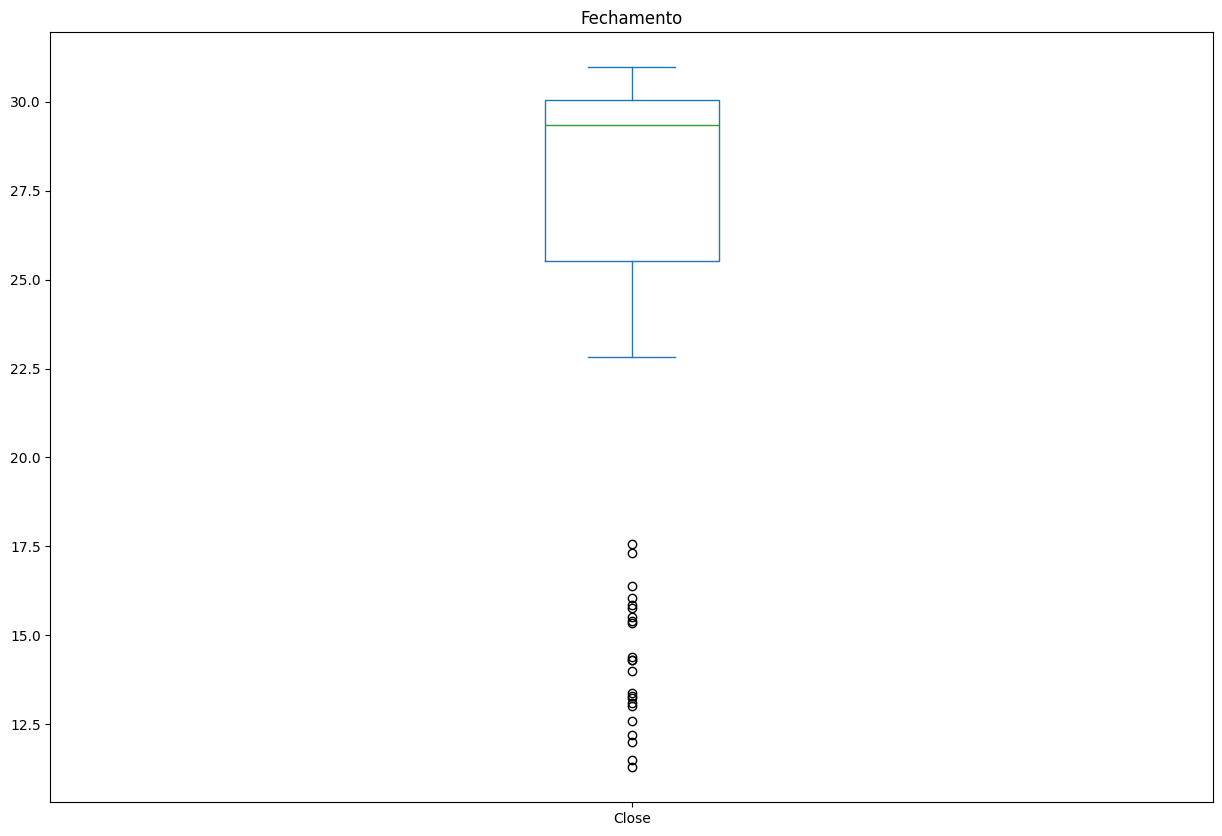

In [38]:
# fechamento:

fechamento_diagrama = df['Close'].plot(kind='box')
fechamento_diagrama.set_title('Fechamento')
plt.show()


Com base no gráfico de caixa gerado para o atributo 'Fechamento' e nos valores calculados anteriormente (Q1, Q3, e limites inferior/superior), entende-se:

1. A Caixa Central do Diagrama: O corpo da caixa (do Q1: 25.52 até o Q3: 30.04) mostra que 50% dos preços de fechamento das ações da Petrobrás, nesse período, variaram entre aproximadamente 25.52 e 30.04. Esta é a faixa onde a maioria das negociações de fechamento ocorreu;

2. A Mediana: A linha dentro da caixa indica o valor mediano dos preços de fechamento;

3. Os "Bigodes": Os "bigodes" do gráfico se referem as linhas que se estendem para baixo, até o menor valor de fechamento observado (que não é considerado um outlier), e para cima, até o maior valor que também não é um outlier. Os limites foram calculados para o filtro de 1.5 (sigma) vezes o Intervalo Interquartil (IQR) (os bigodes não se estenderão além desses pontos):

    * Limite Inferior: 18.73
    * Limite Superior: 36.83

4. Outliers (Pontos Fora dos Bigodes): Qualquer ponto plotado individualmente fora dos 'bigodes' representaria um preço de fechamento excepcionalmente baixo (abaixo de 18.73) ou excepcionalmente alto (acima de 36.83). Esses pontos são considerados anomalias pela regra do box plot (1.5 * IQR).



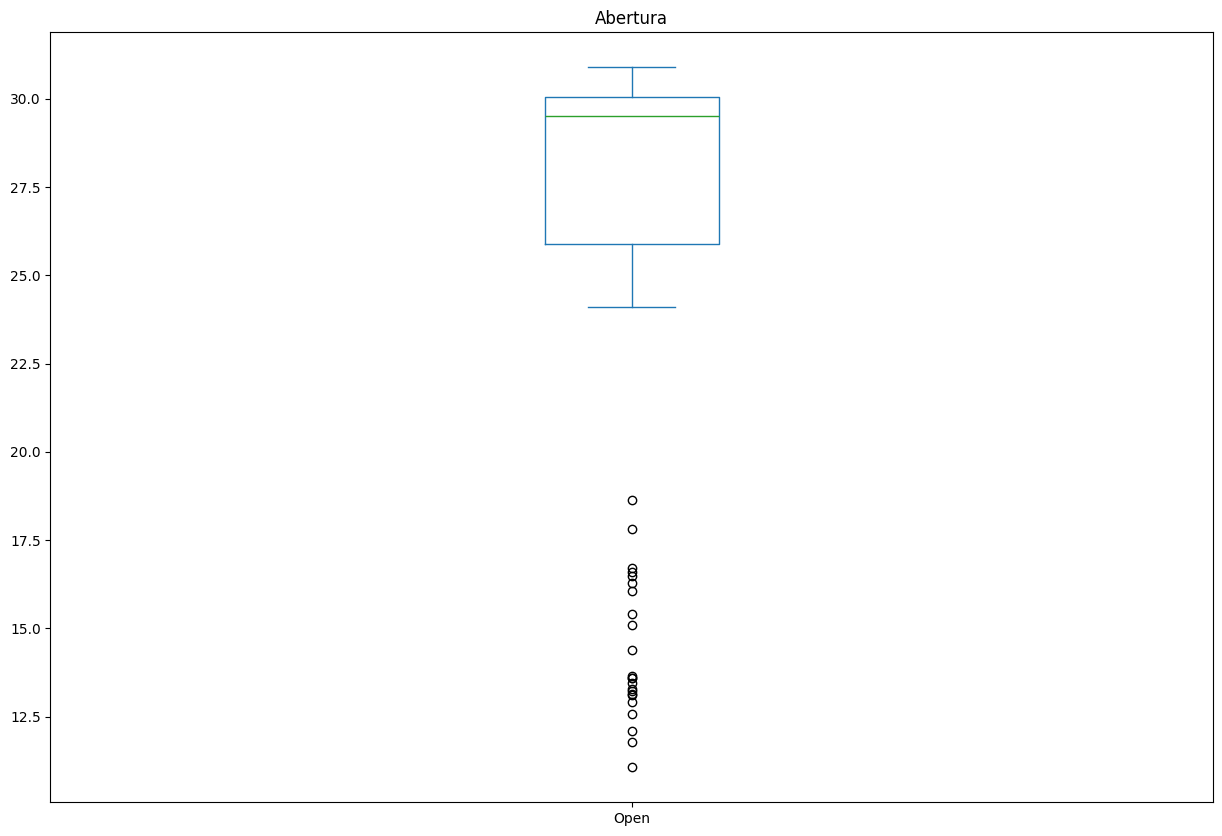

In [39]:
# abertura:

abertura_diagrama = df['Open'].plot(kind='box')
abertura_diagrama.set_title('Abertura')
plt.show()

* A Caixa Central: Os 50% centrais dos preços de abertura das ações da Petrobrás (entre Q1: 25.87 e Q3: 30.05) mostram a faixa mais comum de negociação no início do dia;
* Os "Bigodes": Eles se estenderão até os pontos de dados que não ultrapassam os limites calculados de 19.61 (inferior) e 36.32 (superior). Qualquer preço de abertura fora desses limites seria considerado um outlier;
* Outliers: Os pontos individuais fora dos "bigodes" representam dias com preços de abertura significativamente incomuns (muito baixos ou muito altos) para o período, merecendo atenção para investigar as causas.

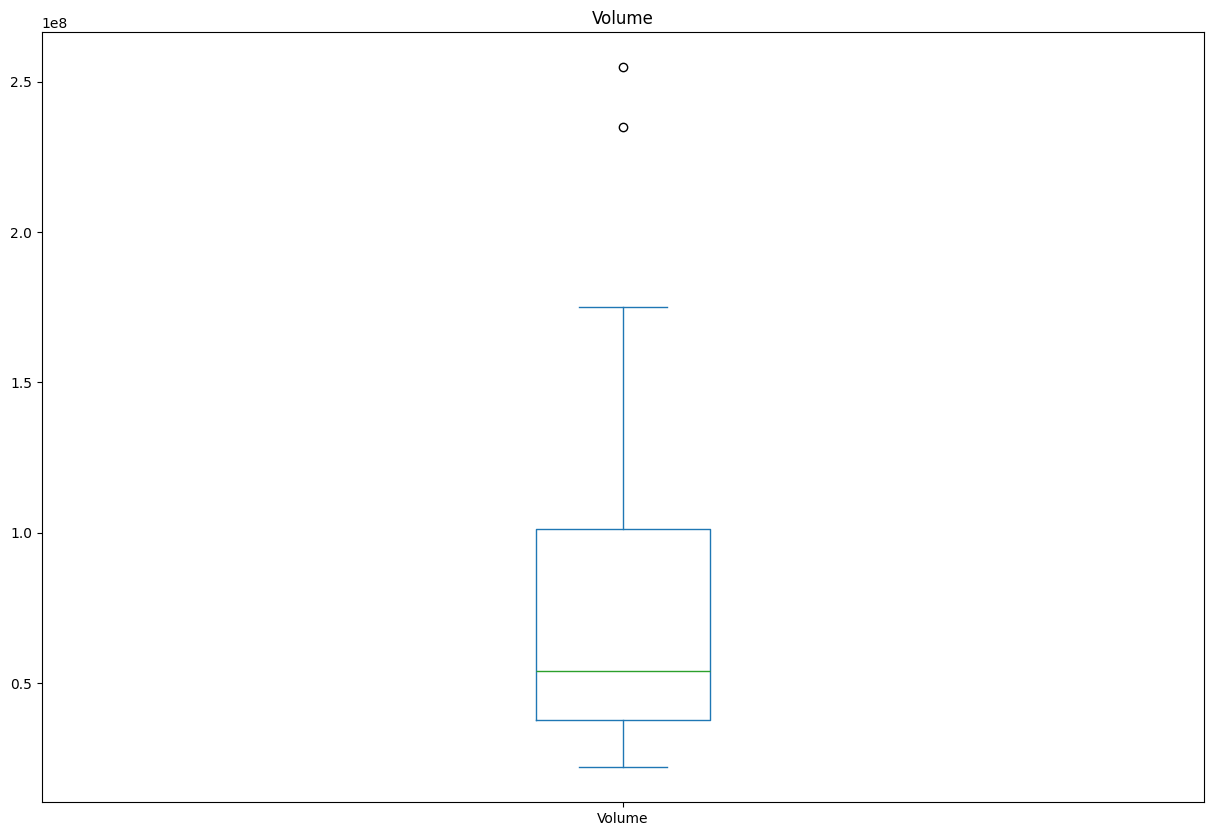

In [40]:
# volume:

volume_diagrama = df['Volume'].plot(kind='box')
volume_diagrama.set_title('Volume')
plt.show()

* A Caixa Central: Os 50% centrais do volume negociado (entre Q1: 37.56 milhões e Q3: 101.36 milhões) indicam a faixa mais frequente de volume de transações;
* Os "Bigodes": Se estendem, no máximo, até os limites calculados de -58.13 milhões (inferior) e 197.05 milhões (superior). (o limite inferior negativo não faz sentido prático para volume, mas é um resultado da regra 1.5 IQR; o bigode inferior, na verdade, irá até o menor volume real de dados (assumindo que seja positivo));
* Outliers: Pontos plotados acima do limite superior de 197.05 milhões de volume representam dias com um volume de negociação excepcionalmente alto, sendo considerados anomalias.